Chapter 2's implementation of a machine learning project, from collecting data to training models

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not (tarball_path.is_file()):
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path = "datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [ ]:
housing_full.head()

In [ ]:
housing_full["ocean_proximity"].value_counts()

In [ ]:
housing_full.describe()

In [ ]:
import matplotlib.pyplot as plt

housing_full.hist(bins= 50, figsize=(12,8))
plt.show()

3 ways to split the test/training set
</br>1: the naive shuffling - not reproducible if the data gets added/deleted
</br>2: uses hashing for shuffling - stable on adding data as well
</br>3: easiest and consistent shuffling, but new data may change the test and training sets

In [ ]:
# creating a test set
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    
    return data.iloc[train_indices], data.iloc[test_indices]

rng = np.random.default_rng(seed=42)
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)

In [ ]:
# from zlib import crc32

# def is_id_in_test_set(id, test_ratio):
#     return crc32(np.int64(id)) < test_ratio * 2**32

# def split_data_with_id_hash(data, test_ratio, id_column):
#     ids = data[id_column]
#     in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
#     return data.loc[~in_test_set], data.loc[in_test_set]

# housing_with_id = housing_full.reset_index()  # adds an `index` column
# housing_with_id["id"] = (housing_full["longitude"] * 1000 + housing_full["latitude"]) #populate with unique indices that depend on stable instance features
# train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")


In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size = 0.2, random_state=42)

In [ ]:
test_set["total_bedrooms"].isnull().sum()

In [ ]:
from scipy.stats import binom

sample_size = 1000
ratio_female = 0.516
proba_too_small = binom(sample_size, ratio_female).cdf(490-1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(540)
print(proba_too_small + proba_too_large)

In [ ]:
# extra code – shows another way to estimate the probability of bad sample

rng = np.random.default_rng(seed=42)
samples = (rng.random((100_000, sample_size)) < ratio_female).sum(axis=1)
((samples < 490) | (samples > 540)).mean()

In [ ]:
# creating a new column for the strata

housing_full["income_cat"] = pd.cut(housing_full["median_income"], 
                                    bins=[0.,1.5,3.0,4.5,6.,np.inf], 
                                    labels=[1,2,3,4,5])

In [ ]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")

plt.show()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

#for getting 10 splits
# splitter = StratifiedShuffleSplit( n_splits=10, test_size=0.2, random_state=42)
# strat_splits=[]

# for train_index, test_index in splitter.split(housing_full, housing_full["income_cat"]):
#     strat_train_set_n = housing_full.iloc[train_index]
#     strat_test_set_n = housing_full.iloc[test_index]
#     strat_splits.append([strat_train_set_n, strat_test_set_n])


# strat_train_set, strat_test_set_ = strat_splits[0]


In [ ]:
#getting only 1 split
strat_train_set, strat_test_set = train_test_split(
    housing_full, test_size=0.2, random_state=42, stratify=housing_full["income_cat"]
)

strat_test_set["income_cat"].value_counts().sort_index() / len(strat_test_set)

In [ ]:
def income_cat_proportions(training_set):
    return training_set["income_cat"].value_counts() / len(training_set)

train_set_r, test_set_r = train_test_split(
    housing_full, random_state=42, test_size=0.2
) 

proportion_table = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_full),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set_r)
}
).sort_index()

proportion_table["Strat. Error%"] = (proportion_table["Stratified %"] / proportion_table["Overall %"] - 1)
proportion_table["Random. Error%"] = (proportion_table["Random %"] / proportion_table["Overall %"] - 1)

del train_set_r
del test_set_r

proportion_table.index.name = "Income Category"
(proportion_table * 100).round(2)

In [ ]:
# for set in (strat_train_set, strat_test_set):
#     set.drop("income_cat", axis=1,inplace=True)

In [ ]:
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude",grid=True, alpha=0.2)
housing.plot(kind="scatter", y="population", x="median_income",grid=True, alpha=0.2)
plt.show()

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude",grid=True, 
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap = "jet", colorbar = True,
             legend = True, sharex=False, figsize=(10,7))

plt.show()

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))

plt.show()

In [ ]:
housing.plot(kind="scatter", x="total_rooms", y="median_house_value", alpha=0.1, grid=True)
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

In [ ]:
housing["rooms_per_house"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_house"] = housing["population"]/housing["households"]

corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
# Separating the predictors from the label
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy() 

In [ ]:
#Cleaning data
#total_bedrooms has some missing datapoints, we can either remove rows with missing data, remove the whole attribute, or fill in the holes with some value

# Underlying logic
# median = housing["total_bedrooms"].median()
# housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

X = imputer.transform(housing_num) #output is an array rn

housing_transformed = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [ ]:
housing_cat = housing[["ocean_proximity"]]
# To convert these strings into number, we use Scikit's Encoder

# from sklearn.preprocessing import OrdinalEncoder
# ordinal_encoder = OrdinalEncoder()
# housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder()
housing_cat_1hot = onehot_encoder.fit_transform(housing_cat)

In [ ]:
# Feature Scaling
# Methods:
#   min-max scaling -> normalization
#   standardization -> creates normal distribution

# from sklearn.preprocessing import MinMaxScaler
# min_max_scaler = MinMaxScaler(feature_range=(-1,1))
# housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)


In [ ]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())
model = LinearRegression()

model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)
predictions

In [ ]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)
predictions

In [ ]:
#Custom Transformer

from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [ ]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1))

age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [ ]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, kw_args= dict(Y=[sf_coords], gamma=0.1))

sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [ ]:
ratio_transformer = FunctionTransformer(lambda X: X[:,[0]] / X[:,[1]])
ratio_transformer.transform(np.array([[1.,2.],[3.,4.],[1,8]]))

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalarClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean = with_mean
    
    def fit(self, X, y=None):
        X = check_array(X)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]
        return self
    
    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
            
        return X / self.std_
        

In [ ]:
#Kmean Transformer

from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0,random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight) 
        self.n_features_in_ = X.shape[1]
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster{i} similarity" for i in range(self.n_clusters)]
    


In [ ]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

similarities[:3].round(2)

In [ ]:
housing_renamed = housing.rename(columns={
    "latitude" : "Latitude", "longitude": "Longitude", "population": "Population",
    "median_house_value": "Median_house_vale (usd)"
})

housing_renamed["mcs"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x = "Longitude", y = "Latitude", grid = True,
                     s=housing_renamed["Population"]/100, label = "Population",
                     c = "mcs", cmap = "jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10,7))

plt.plot(cluster_simil.kmeans_.cluster_centers_[:,1], cluster_simil.kmeans_.cluster_centers_[:,0],
         linestyle="", marker="X", color="black", markersize="10", label = "Cluster centers")

plt.legend(loc = "upper right")
plt.show()

In [ ]:
#pipeline

import sklearn
sklearn.set_config(display="diagram")

from sklearn.pipeline import Pipeline, make_pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)
df_hnp = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(), index=housing_num.index
)

num_pipeline["simpleimputer"]

In [ ]:
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

num_attribs = ["longtitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"),
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

housing_prepared = preprocessing.fit_transform(housing)
df_hp = pd.DataFrame(housing_prepared, columns=preprocessing.get_feature_names_out(), index=housing.index)
df_hp.describe().round(2)

In [ ]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name), 
        StandardScaler()
    )
    
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
], remainder=default_num_pipeline)

In [ ]:
housing_prepared = preprocessing.fit_transform(housing)
preprocessing.get_feature_names_out()

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(2)

In [ ]:
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42, max_depth=10))
tree_reg.fit(housing, housing_labels)   

housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(tree_rmses).describe().round(2)

In [ ]:
linear_rmses = -cross_val_score(lin_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(linear_rmses).describe()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
# forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
# pd.Series(forest_rmses).describe()

In [ ]:
from sklearn.model_selection import GridSearchCV
from tempfile import mkdtemp

cachedir = mkdtemp()

# full_pipeline = Pipeline([
#     ("preprocessing", preprocessing),
#     ("decision_tree", DecisionTreeRegressor(random_state=42)),
# ], memory=cachedir)

# param_grid = [
#     {'preprocessing__geo__n_clusters': [5, 8, 10],
#      'decision_tree__max_depth': [7, 9]},
#     {'preprocessing__geo__n_clusters': [10, 15],
#      'decision_tree__max_depth': [10, 15, 11]},
# ]

# grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error")
# grid_search.fit(housing, housing_labels)

# grid_search.best_params_

In [ ]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
], memory = cachedir)

# param_grid = [
#     {'preprocessing__geo__n_clusters': [10, 15, 20, 25],
#      'random_forest__max_features': [4, 6, 8]},
# ]

# grid_search_f = GridSearchCV(full_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error")
# grid_search_f.fit(housing, housing_labels)

# grid_search_f.best_params_

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=20)
}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring="neg_root_mean_squared_error", random_state=42
)

rnd_search.fit(housing, housing_labels)
rnd_search.best_params_

In [ ]:
print(f"Best Parameters: {rnd_search.best_params_}")
print(f"Best Score: {-rnd_search.best_score_.round(2)}")

selector_rmses = -cross_val_score(full_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(selector_rmses).describe()

In [ ]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_

# sorted(zip(feature_importances,
#            final_model["preprocessing"].get_feature_names_out()),
#        reverse=True)

In [ ]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

In [ ]:
from scipy.stats import bootstrap

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test)**2
boot_result = bootstrap([squared_errors], rmse, confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [ ]:
print(f"95% CI for RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

In [ ]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

In [ ]:
from sklearn.svm import SVR
from sklearn.feature_selection import SelectFromModel

svm_cache = mkdtemp()

estimator = SVR()
# selector = SelectFromModel(RandomForestRegressor(random_state=42, threshold=0.005))

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    # ("selection", selector),
    ("SVM", estimator)
],memory=svm_cache )

full_pipeline

In [ ]:
from scipy.stats import expon, loguniform

param_distribs = [
    {"SVM__kernel": ["rbf", "linear"],
    "SVM__C": randint(low=1,high=200000),
    "SVM__gamma": expon(scale=1.0)}
]

svm_rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring="neg_root_mean_squared_error", random_state=42
)

X_svm = housing.iloc[:5000].drop("income_cat", axis=1)
y_svm = housing_labels.iloc[:5000]

In [ ]:
svm_rnd_search.fit(X_svm, y_svm)
svm_model = svm_rnd_search.best_estimator_

In [ ]:
print(f"Best Parameters: {svm_rnd_search.best_params_}")
print(f"Best Score: {-svm_rnd_search.best_score_.round(2)}")

In [ ]:
selector_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('selector', SelectFromModel(RandomForestRegressor(random_state=42),
                                 threshold=0.005)),  # min feature importance
    ('svr', SVR(C=svm_rnd_search.best_params_["SVM__C"],
                gamma=svm_rnd_search.best_params_["SVM__gamma"],
                kernel=svm_rnd_search.best_params_["SVM__kernel"])),
])

selector_rmses = -cross_val_score(selector_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(selector_rmses).describe()

In [78]:
from sklearn.neighbors import KNeighborsRegressor

class KNN_regressor(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbours=5, leaf_size=30, weights="uniform" ):
        self.n_neighbours = n_neighbours
        self.leaf_size = leaf_size
        self.weights = weights
        
    #pass in longitude and latitude
    def fit(self, X, y):
        self.knn_ = KNeighborsRegressor(n_neighbors=self.n_neighbours, leaf_size=self.leaf_size, weights=self.weights)
        self.knn_.fit(X,y) 
        self.n_features_in_ = X.shape[1]
        return self
    
    def predict(self, X):
        return self.knn_.predict(X)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster{i} similarity" for i in range(self.n_clusters)]
    

<Axes: xlabel='longitude', ylabel='latitude'>

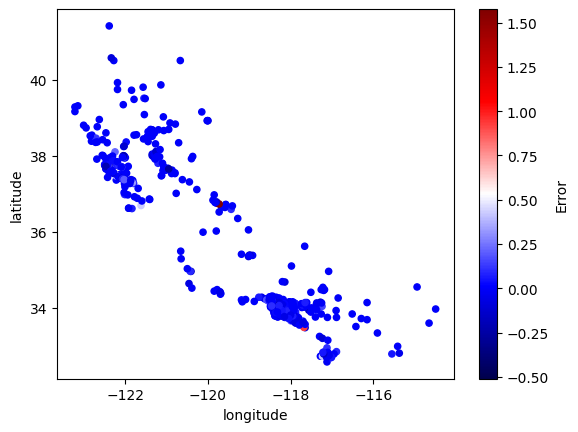

In [113]:
test = KNN_regressor(4, 10, "distance")

X = housing[["longitude", "latitude"]]
test.fit(X, housing_labels)
predictions = test.predict(housing[["longitude", "latitude"]].iloc[:500])

knn = pd.DataFrame({
    "Predicted": predictions,
    "Real": housing_labels.iloc[:500],
    "Error": (predictions/housing_labels.iloc[:500] - 1).round(3)
}).sort_index()

# housing.plot(kind="scatter", x="longitude", y="latitude")
knn["longitude"] = housing["longitude"]
knn["latitude"] = housing["latitude"]

knn.plot(kind="scatter", x="longitude", y="latitude",
         c="Error", cmap="seismic", colorbar=True)
    
